In [141]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from pathlib import Path
import plotly.express as px
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

import logging
logger = logging.getLogger(__name__)

In [39]:
logging.basicConfig(format='%(asctime)s|%(levelname)s|%(message)s',
                    # filename='output.log', 
                    encoding='utf-8', 
                    level=logging.DEBUG)
logger = logging.getLogger(__name__)

In [40]:
class TripletLossEmbeddingModel(nn.Module):
    """
    Implements the TripletLossEmbeddingModel.
    This model learns representations from input features by training an embedding layer with a triplet margin loss function.
    Training input are triplets of features for anchor, positive, negative samples.
    """
    def __init__(self, input_dim, embed_dim):
        super(TripletLossEmbeddingModel, self).__init__()
        # Create the shared embedding layer
        self.embedding = nn.Linear(input_dim, embed_dim)

    def forward(self, x):
        # Compute embeddings
        return F.normalize(self.embedding(x), p=2, dim=1)

In [41]:
class ContrastiveLossEmbeddingModel(nn.Module):
    """
    Implements the ContrastiveLossEmbeddingModel.
    Implementation is nearly identical to TripletLossEmbeddingModel
    """
    def __init__(self, input_dim, embed_dim):
        super(ContrastiveLossEmbeddingModel, self).__init__()
        # Create the shared embedding layer
        self.embedding = nn.Linear(input_dim, embed_dim)

    def forward(self, x):
        # Compute embeddings
        return F.normalize(self.embedding(x), p=2, dim=1)

In [42]:
class TripletDataset(Dataset):
    """
    Implement triplet dataset class.
    """
    def __init__(self, x_anchors, x_positives, x_negatives):
        assert x_anchors.shape == x_positives.shape == x_negatives.shape
        self.num_samples, self.input_dim = x_anchors.shape
        self.anchors = x_anchors
        self.positives = x_positives
        self.negatives = x_negatives
        
    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return (
            torch.tensor(self.anchors[idx], dtype=torch.float32),
            torch.tensor(self.positives[idx], dtype=torch.float32),
            torch.tensor(self.negatives[idx], dtype=torch.float32)
        )

In [43]:
class ContrastiveDataset(Dataset):
    """
    Implement contrastive dataset class.
    """
    def __init__(self, x1, x2, labels):
        assert x1.shape == x2.shape
        assert len(labels) == len(x1)
        self.num_samples, self.input_dim = x1.shape
        self.x1 = x1
        self.x2 = x2
        self.labels = labels
        
    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return (
            torch.tensor(self.x1[idx].detach().clone(), dtype=torch.float32),
            torch.tensor(self.x2[idx].detach().clone(), dtype=torch.float32),
            torch.tensor(self.labels[idx].detach().clone(), dtype=torch.float32)
        )

In [44]:
class ContrastiveLoss(nn.Module):
    """
    Because PyTorch does not have a built-in contrastive loss function, we create one.
    """
    def __init__(self, margin=1.0, dist_func=None):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

        if dist_func is None:
            self.dist_func = F.pairwise_distance
        else:
            self.dist_func = dist_func

    def forward(self, output1, output2, label):
        distances = self.dist_func(output1, output2)
        loss = torch.mean(label * distances.pow(2) +
                          (1 - label) * F.relu(self.margin - distances).pow(2))
        return loss

In [45]:
def cosine_distance(x1, x2):
    """
    Implement a cosine_distance function as PyTorch does not have a built-in one.
    """
    x1 = F.normalize(x1, p=2, dim=1)
    x2 = F.normalize(x2, p=2, dim=1)
    cosine_sim = torch.sum(x1 * x2, dim=1)
    return 1 - cosine_sim  # convert similarity to distance


def train_contrastive_loss(dataset, embed_dim,
                       dist_func=None,
                       margin=1.0,
                       batch_size=256,
                       epochs=10,
                       lr=0.001
                       ):
    """
    Training loop for triplet margin loss.

    Args:
        dataset (ContrastiveLossDataset) : The training dataset.
        embed_dim (int) : The size of the embedding vectors.
        dist_func (callable) : If using custom distance function (default is Euclidean distance).
        margin (float) : The size of the margin learned (larger forces more separation between positive and negative).
        batch_size (int) : Training batch size.
        epochs (int) : Training epochs.
        lr (float) : The learning rate.

    Returns:
        model (ContrastiveLossEmbeddingModel) : The trained model.
        loss (np.array(float)) : The training loss for each epoch.
    """

    input_dim = dataset.input_dim
    model = ContrastiveLossEmbeddingModel(input_dim, embed_dim)

    # Create loss function module
    criterion = ContrastiveLoss(margin, dist_func)

    # Init optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # Training loop
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    loss_history = np.zeros(epochs)
    for i_e, epoch in enumerate(range(epochs)):
        total_loss = 0
        for x1, x2, labels in dataloader:
            optimizer.zero_grad()
            # Forward pass
            x1_embed = model(x1)
            x2_embed = model(x2)
            # Compute loss
            loss = criterion(x1_embed, x2_embed, labels)
            # Backpropagation
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        loss_history[i_e] = total_loss
        
        logging.debug(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(dataloader):.4f}")

    return model, loss_history
    

In [46]:
def train_triplet_loss(dataset, embed_dim,
                       dist_func=None,
                       margin=1.0,
                       batch_size=256,
                       epochs=10,
                       lr=0.001
                       ):
    """
    Training loop for triplet margin loss.

    Args:
        dataset (TripletDataset) : The training dataset.
        embed_dim (int) : The size of the embedding vectors.
        dist_func (callable) : If using custom distance function (default is Euclidean distance).
        margin (float) : The size of the margin learned (larger forces more separation between positive and negative).
        batch_size (int) : Training batch size.
        epochs (int) : Training epochs.
        lr (float) : The learning rate.

    Returns:
        model (TripletLossEmbeddingModel) : The trained model.
        loss (np.array(float)) : The training loss for each epoch.
    """

    input_dim = dataset.input_dim
    model = TripletLossEmbeddingModel(input_dim, embed_dim)

    if dist_func is None:
        criterion = nn.TripletMarginLoss(margin=margin, p=2)
    else:
        criterion = nn.TripletMarginWithDistanceLoss(margin=margin, 
                                                     distance_function=dist_func)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # Training loop
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    loss_history = np.zeros(epochs)
    for i_e, epoch in enumerate(range(epochs)):
        total_loss = 0
        for anchor, positive, negative in dataloader:
            optimizer.zero_grad()
            
            # Forward pass
            anchor_embed = model(anchor)
            positive_embed = model(positive)
            negative_embed = model(negative)
            
            # Compute loss
            loss = criterion(anchor_embed, positive_embed, negative_embed)
            
            # Backpropagation
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        loss_history[i_e] = total_loss
        
        logging.debug(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(dataloader):.4f}")

    return model, loss_history

In [47]:
# Example usage
input_dim = 384  # Just like SBERT embeddings
embed_dim = 64  # Chosen embedding dimension

# Sample random set
a = torch.randn(100, input_dim)
pos = torch.randn(100, input_dim)
neg = torch.randn(100, input_dim) + 10
# Create a TripletDataset with the generated data.
dataset = TripletDataset(a, pos, neg)
model, loss = train_triplet_loss(dataset, embed_dim)
logger.info(f"(Triplet) Trained model. Loss: {loss}")

# Example usage for Contrastive Loss
###########################################################
# Generate random "input vectors"
x1 = torch.randn(300, input_dim)
#column from pd df, sbert embedings
x2 = torch.randn(300, input_dim)
margin = 1.0  # Choose a margin
# Random labels: 0 if dissimilar, 1 if similar.
#make the labels if similar 1, 0 if not
labels = torch.randint(0, 2, (len(x1), ), dtype=torch.float32)

logger.info(f"{x1.shape}, {x2.shape}, {labels.shape}")
dataset = ContrastiveDataset(x1, x2, labels)
model, loss = train_contrastive_loss(dataset, embed_dim, margin=margin, epochs=20)
logger.info(f"Model trained!")

# Get embedding for new inputs

x_test = torch.randn(3, input_dim)
###these have the datapoints, stack of vectors of sbert,   # 3 random input vectors
x_test_emb = model(x_test)  # Get embeddings for each of the 3 inputs
print(x_test_emb.shape) 

torch.Size([3, 64])


/tmp/ipykernel_3565251/1389304664.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.anchors[idx], dtype=torch.float32),
/tmp/ipykernel_3565251/1389304664.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.positives[idx], dtype=torch.float32),
/tmp/ipykernel_3565251/1389304664.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.negatives[idx], dtype=torch.float32)
/tmp/ipykernel_3565251/2184046708.py:20: UserWarning: To copy construct from a tensor, it is recommended to use source

In [122]:

def vectorize(series):
    """
    Takes a pandas Series of embedding_json strings
    and returns a NumPy array of shape (N, 384).
    """
    # Ensure string
    s = series.astype(str).str.strip()

    # Remove brackets, split into float lists
    vecs = (
        s.str[1:-1]                   # strip '[' and ']'
         .str.split(',')              # split by comma
         .apply(lambda x: np.array(x, dtype=np.float32))
         .tolist()
    )

    # Stack into (n_samples, embed_dim)
    return np.vstack(vecs)

In [ ]:
global_db = pd.read_csv('/data/elugos/global_db_111125.csv')
df_play_sample = pd.read_csv(Path('/data/elugos/df_play_sampled.csv'))



In [100]:
def clean_sample(df,global_db):
    ## get longest sbert text
    df["text_len"] = df["sbert_text"].str.len()
    df_clean = df.sort_values("text_len", ascending=False).drop_duplicates(subset="GlobalEventID", keep="first")
    df_clean = df_clean.drop(columns=["text_len"])
    ## get all rows that exist in df from global_db and clean to make sure they match, drop all other rows
    ids = df_clean["GlobalEventID"]
    global_play_db = global_db[global_db["GlobalEventID"].isin(ids)].copy()
    valid_ids = set(global_play_db["GlobalEventID"])
    df_clean = df_clean[df_clean["GlobalEventID"].isin(valid_ids)].copy()
    ## add globaldb to df_clean
    df_clean = df_clean.merge(
    global_play_db,
    on="GlobalEventID",
    how="left",
    suffixes=("", "_db")
)

    return df_clean,global_play_db

In [101]:
df_play_sample,global_play_db = clean_sample(df_play_sample,global_db)


In [75]:
cameo_codes = {
    "MAKE PUBLIC STATEMENT": "1",
    "APPEAL": "2",
    "EXPRESS INTENT TO COOPERATE": "3",
    "CONSULT": "4",
    "ENGAGE IN DIPLOMATIC COOPERATION": "5",
    "ENGAGE IN MATERIAL COOPERATION": "6",
    "PROVIDE AID": "7",
    "YIELD": "8",
    "INVESTIGATE": "9",
    "DEMAND": "10",
    "DISAPPROVE": "11",
    "REJECT": "12",
    "THREATEN": "13",
    "PROTEST": "14",
    "EXHIBIT FORCE POSTURE": "15",
    "COERCE": "16",
    "ASSAULT": "17",
    "FIGHT": "19",
    "USE UNCONVENTIONAL MASS VIOLENCE": "20",
}

In [ ]:
### can plot this with tsne and color code
x_test_emb

tensor([[ 0.1701,  0.1867,  0.0618,  0.2171,  0.0152,  0.3048, -0.0228, -0.2302,
          0.0068,  0.0892, -0.1255, -0.1271, -0.0754, -0.0405, -0.0982, -0.1738,
         -0.0402,  0.1799, -0.0513,  0.0761,  0.0501, -0.0602, -0.0586,  0.0025,
          0.0229,  0.0569, -0.0059,  0.0158,  0.0585,  0.1280, -0.0489,  0.1445,
          0.0164,  0.0343,  0.0043, -0.0728,  0.0821, -0.1636, -0.0608, -0.0594,
          0.0819, -0.0640,  0.1204, -0.1646, -0.2029,  0.0112, -0.0868, -0.0692,
         -0.0682,  0.0133,  0.0809, -0.2074, -0.0265, -0.0933, -0.0869,  0.3153,
         -0.3152,  0.1703,  0.0314,  0.0622, -0.2213, -0.1691,  0.0653,  0.1144],
        [-0.1102, -0.1371, -0.2801,  0.0736, -0.0604,  0.0473,  0.0578, -0.1276,
          0.1266,  0.0987,  0.2837, -0.0705,  0.1278, -0.0037, -0.0210, -0.0587,
          0.0528, -0.0542, -0.0009,  0.0537, -0.0964,  0.1054, -0.0511,  0.0261,
          0.0485,  0.1709, -0.0202, -0.0609, -0.0824, -0.2020,  0.0096, -0.0905,
          0.0093, -0.0341, 

In [ ]:
##plot loss history
#$# array of embeddings
# try tsne 

In [154]:
def make_sampler(df):
    # sample i and j
    i = df.sample(n=1000, random_state=42)
    remaining = df.drop(i.index)
    j = remaining.sample(n=1000, random_state=43)

    # reset index so pairs line up
    i = i.reset_index(drop=True)
    j = j.reset_index(drop=True)

    # Extract only the FIRST part of EventCode (before underscore)
    i_event_major = i["EventCode"].astype(str).str.split("_").str[-1]
    j_event_major = j["EventCode"].astype(str).str.split("_").str[-1]

    # Build sampler
    sampler = pd.DataFrame({
        "GlobalEventID-i": i["GlobalEventID"],
        "GlobalEventID-j": j["GlobalEventID"],
        "embedding_json-i": i["embedding_json"],
        "embedding_json-j": j["embedding_json"],
    })

    # y = 1 if the FIRST XX match, else 0
    sampler["y"] = (i_event_major.values == j_event_major.values).astype(int)

    return sampler




In [155]:
sampler = make_sampler(df_play_sample)

In [156]:
sampler

,GlobalEventID-i,GlobalEventID-j,embedding_json-i,embedding_json-j,y
0,1269298662,549679788,"[0.015435556881129742, 0.051698312163352966, -...","[0.04171710088849068, 0.02688223123550415, -0....",0
1,1213264809,1170943903,"[0.0087357172742486, 0.03770238533616066, 0.08...","[0.07626461982727051, 0.006777334958314896, -0...",0
2,1268733328,1269549801,"[-0.07486459612846375, 0.10648536682128906, 0....","[0.015490593388676643, -0.008042097091674805, ...",0
3,1219046372,1268646835,"[-0.015838883817195892, -0.00835991371423006, ...","[-0.009270140901207924, 0.08723805844783783, -...",0
4,1169732572,1247621260,"[0.02182798832654953, -0.024596083909273148, 0...","[-0.06820932775735855, -0.01640196703374386, 0...",0
...,...,...,...,...,...
995,1213635982,1269082923,"[0.004809727426618338, 0.038895051926374435, -...","[-0.05758175998926163, -0.005920943804085255, ...",0
996,1219937513,1170245100,"[0.09070782363414764, -0.03777722269296646, -0...","[-0.05874742567539215, 0.029912451282143593, 0...",1
997,1213739802,1247595602,"[0.014364615082740784, -0.03459899500012398, -...","[0.0691642090678215, -0.03266007825732231, 0.0...",0
998,925692773,703464096,"[0.0398612916469574, -0.004832133185118437, 0....","[-0.026476332917809486, 0.048140089958906174, ...",0


In [157]:
# Example usage for Contrastive Loss
###########################################################
# Generate random "input vectors"
#x1 = torch.randn(300, input_dim)
#column from pd df, sbert embedings
#x2 = torch.randn(300, input_dim)

input_dim = 384  # Just like SBERT embeddings
embed_dim = 64  # Chosen embedding dimension
margin = 1.0  # Choose a margin

i_np = vectorize(sampler["embedding_json-i"])
j_np = vectorize(sampler["embedding_json-j"])

i = torch.from_numpy(i_np)
j = torch.from_numpy(j_np)
# Random labels: 0 if dissimilar, 1 if similar.
#make the labels if similar 1, 0 if not
labels = torch.tensor(sampler["y"].values, dtype=torch.float32)

logger.info(f"{i.shape}, {j.shape}, {labels.shape}")


In [158]:
dataset = ContrastiveDataset(i, j, labels)
model, loss = train_contrastive_loss(dataset, embed_dim, margin=margin, epochs=20)
logger.info(f"Model trained!")

# Get embedding for new inputs

#x_test = torch.randn(3, input_dim)
###these have the datapoints, stack of vectors of sbert,   # 3 random input vectors
#x_test_emb = model(x_test)  # Get embeddings for each of the 3 inputs
#print(x_test_emb.shape) 



/tmp/ipykernel_3565251/2184046708.py:18: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).

/tmp/ipykernel_3565251/2184046708.py:19: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).

/tmp/ipykernel_3565251/2184046708.py:20: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).



In [159]:
loss

array([0.43343595, 0.33807138, 0.2762481 , 0.22710467, 0.18923042,
       0.15789659, 0.13190237, 0.1110627 , 0.09379859, 0.07998628,
       0.06747369, 0.0571927 , 0.0488231 , 0.04166953, 0.03573146,
       0.03036187, 0.02618488, 0.02236108, 0.01922148, 0.01652147])

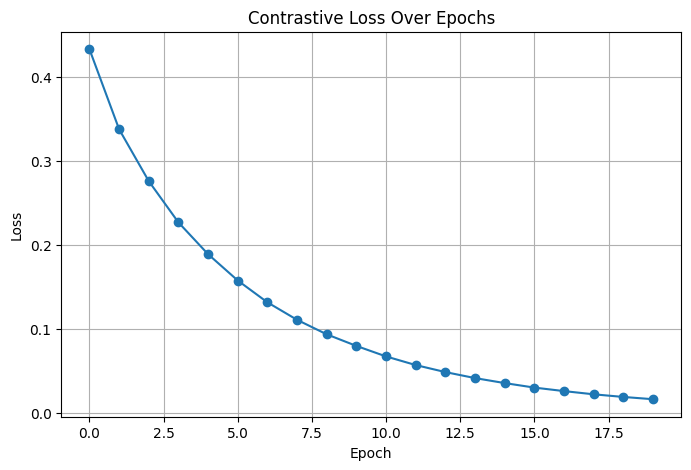

In [160]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(loss, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Contrastive Loss Over Epochs")
plt.grid(True)
plt.show()

In [161]:
# merge metadata for i
meta_i = sampler[["GlobalEventID-i"]].merge(
    global_db[["GlobalEventID", "EventCode"]],
    left_on="GlobalEventID-i",
    right_on="GlobalEventID",
    how="left"
).drop(columns=["GlobalEventID"]).rename(columns={"EventCode": "EventCode-i"})

# merge metadata for j
meta_j = sampler[["GlobalEventID-j"]].merge(
    global_db[["GlobalEventID", "EventCode"]],
    left_on="GlobalEventID-j",
    right_on="GlobalEventID",
    how="left"
).drop(columns=["GlobalEventID"]).rename(columns={"EventCode": "EventCode-j"})


In [165]:
model.eval()

with torch.no_grad():
    i_embed = model(i).cpu().numpy()   # shape: (N, embed_dim)
    j_embed = model(j).cpu().numpy()   # shape: (N, embed_dim)
all_embeddings = np.vstack([i_embed, j_embed])

global_ids = np.concatenate([sampler["GlobalEventID-i"].values,
                             sampler["GlobalEventID-j"].values])

eventcodes = np.concatenate([
    meta_i["EventCode-i"].astype(str).str.rsplit("_", n=1).str[-1].values,
    meta_j["EventCode-j"].astype(str).str.rsplit("_", n=1).str[-1].values
])


all_labels = np.concatenate([labels.numpy(), labels.numpy()])
pair_flag   = np.array([0]*len(i_embed) + [1]*len(j_embed))  # blue = i, orange = j


In [166]:
emb2d_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(all_embeddings)

emb2d_pca = PCA(n_components=2).fit_transform(all_embeddings)


In [168]:
df_plot = pd.DataFrame({
    "x": emb2d_tsne[:,0],
    "y": emb2d_tsne[:,1],
    "GlobalEventID": global_ids,
    "EventCode": eventcodes.astype(int)
})

fig = px.scatter(
    df_plot,
    x="x",
    y="y",
    color="EventCode",
    hover_data=["GlobalEventID", "EventCode"],
    title="Learned Embeddings Colored by EventCode"
)

fig.update_traces(marker=dict(size=6, opacity=0.85))
fig.update_layout(width=900, height=600)
fig.show()

In [ ]:
df_plot = pd.DataFrame({
    "x": emb2d_pca[:,0],
    "y": emb2d_pca[:,1],
    "GlobalEventID": global_ids,
    
    "EventCode": eventcodes.astype(int)
})

fig = px.scatter(
    df_plot,
    x="x",
    y="y",
    color="EventCode",
    hover_data=["GlobalEventID", "EventCode"],
    title="Learned Embeddings Colored by EventCode"
)

fig.update_traces(marker=dict(size=6, opacity=0.85))
fig.update_layout(width=900, height=600)
fig.show()